In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

1. BAGIAN A : OPERASI PADA SINYAL 1D

A1. Membuat Sinyal Diskrit

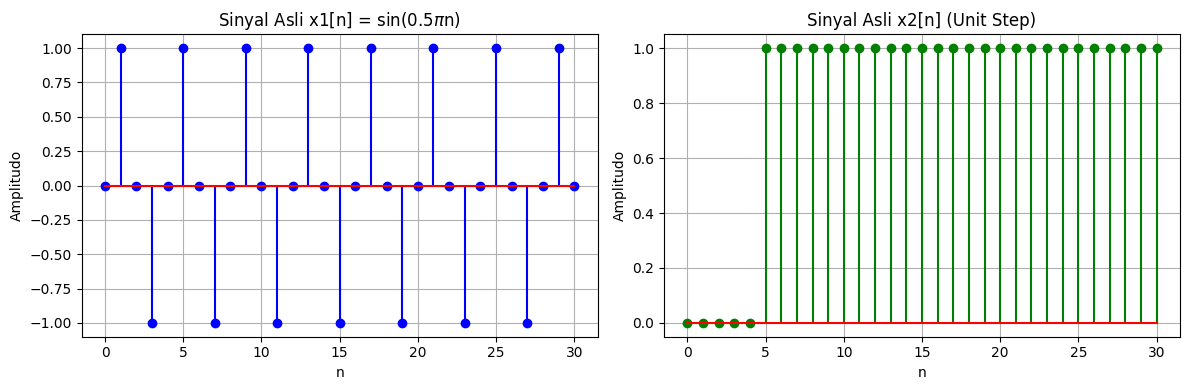

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Menentukan rentang nilai n (0 sampai 30)
n = np.arange(0, 31)

# 2. Membuat Sinyal pertama: x1[n] = sin(0.5 * pi * n)
x1 = np.sin(0.5 * np.pi * n)

# 3. Membuat Sinyal kedua: unit step (0 jika n < 5, 1 jika n >= 5)
x2 = np.where(n >= 5, 1.0, 0.0)

# 4. Visualisasi Plot A.1 (Menampilkan x1 dan x2)
plt.figure(figsize=(12, 4))

# Plot x1[n]
plt.subplot(1, 2, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Sinyal Asli x1[n] = sin(0.5$\\pi$n)')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

# Plot x2[n]
plt.subplot(1, 2, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Sinyal Asli x2[n] (Unit Step)')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.tight_layout()
plt.show()

A2. Operasi Penjumlahan Sinyal

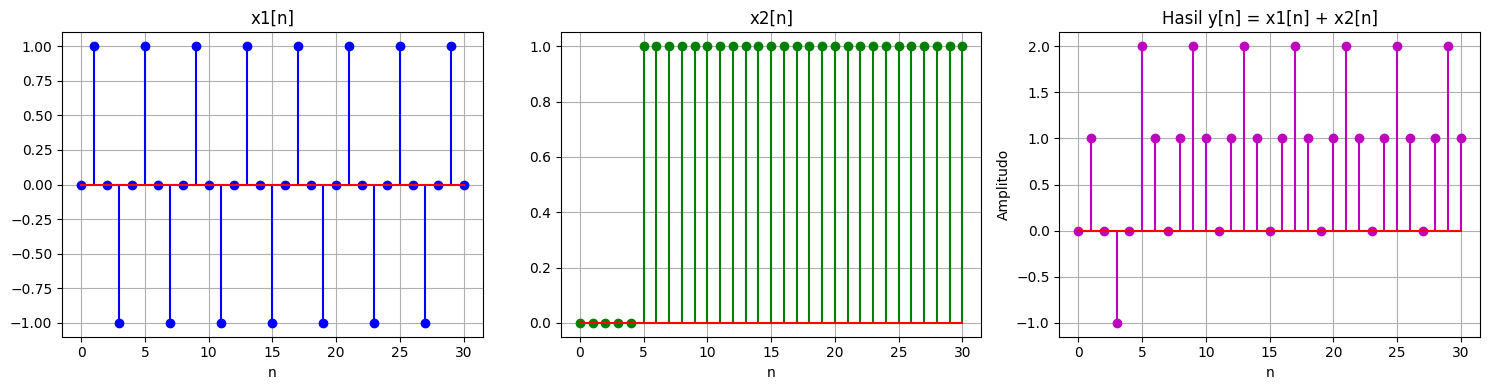

In [5]:
# 1. Operasi Penjumlahan Sinyal
y_add = x1 + x2

# 2. Visualisasi Plot A.2 (Menampilkan x1, x2, dan y)
plt.figure(figsize=(15, 4))

# Plot x1[n]
plt.subplot(1, 3, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('x1[n]')
plt.xlabel('n')
plt.grid(True)

# Plot x2[n]
plt.subplot(1, 3, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('x2[n]')
plt.xlabel('n')
plt.grid(True)

# Plot hasil y[n]
plt.subplot(1, 3, 3)
plt.stem(n, y_add, linefmt='m-', markerfmt='mo', basefmt='r-')
plt.title('Hasil y[n] = x1[n] + x2[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.tight_layout()
plt.show()

A3. Operasi Penggeseran Sinyal

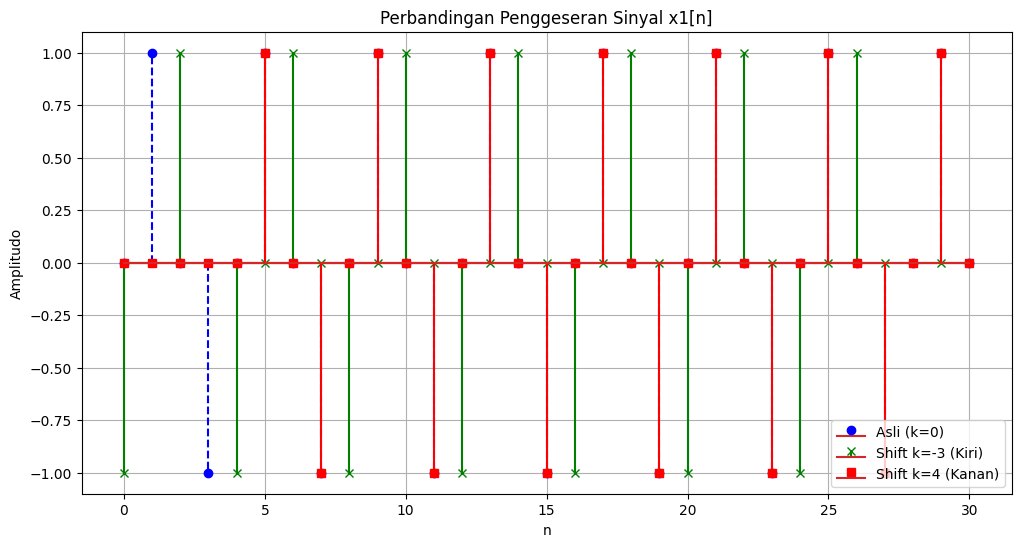

In [6]:
def shift_signal(x, k):
    if k >= 0:
        return np.concatenate((np.zeros(k), x[:len(x)-k]))
    else:
        return np.concatenate((x[-k:], np.zeros(-k)))

# Lakukan penggeseran pada sinyal x1[n]
y_shift_neg3 = shift_signal(x1, -3)
y_shift_0 = shift_signal(x1, 0)
y_shift_pos4 = shift_signal(x1, 4)

# Plot perbandingan dalam satu gambar [cite: 68]
plt.figure(figsize=(12, 6))
plt.stem(n, x1, linefmt='b--', markerfmt='bo', label='Asli (k=0)')
plt.stem(n, y_shift_neg3, linefmt='g-', markerfmt='gx', label='Shift k=-3 (Kiri)')
plt.stem(n, y_shift_pos4, linefmt='r-', markerfmt='rs', label='Shift k=4 (Kanan)')
plt.title('Perbandingan Penggeseran Sinyal x1[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.legend()
plt.grid(True)
plt.show()

A4. Operasi Amplifikasi Sinyal

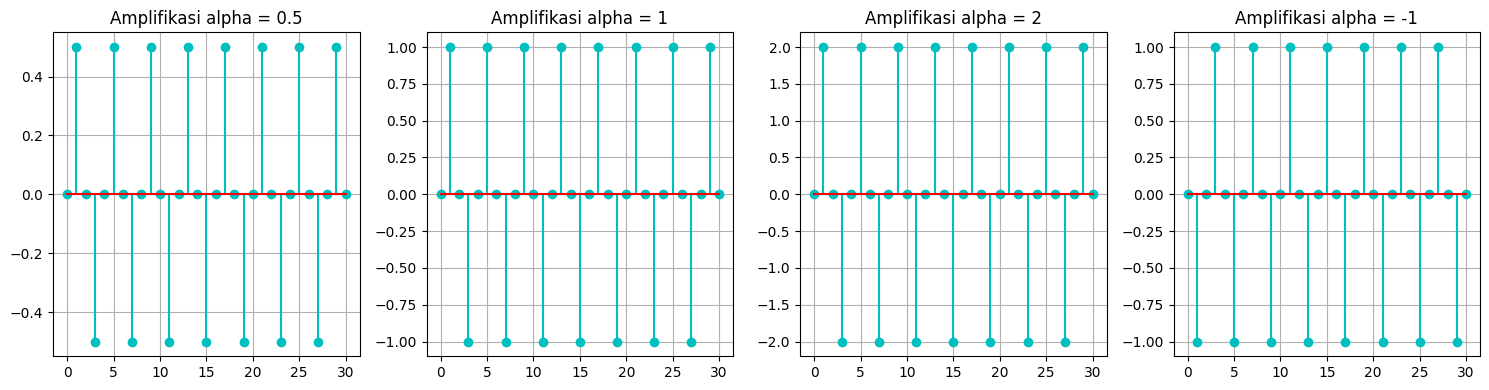

In [12]:
alphas = [0.5, 1, 2, -1]
plt.figure(figsize=(15, 4))

for i, alpha in enumerate(alphas):
    y_amp = alpha * x1 # Operasi amplifikasi [cite: 77]
    plt.subplot(1, 4, i+1)
    plt.stem(n, y_amp, linefmt='c-', basefmt='r-')
    plt.title(f'Amplifikasi alpha = {alpha}')
    plt.grid(True)

plt.tight_layout()
plt.show()

2. BAGIAN B : OPERASI PADA CITRA 2D

B1. Membaca dan Menampilkan Citra

--- Properti Citra Asli ---
Ukuran Citra (Resolusi): (580, 464)
Tipe Data Citra: uint8
Nilai Minimum Pixel: 0
Nilai Maksimum Pixel: 237


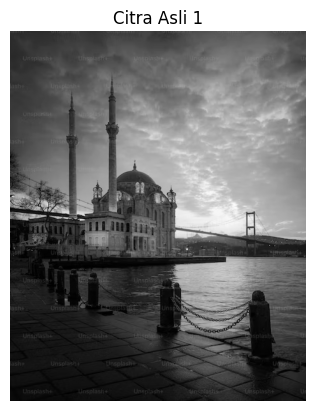

In [16]:
import cv2
import matplotlib.pyplot as plt

# Membaca gambar (Pastikan file sudah di-upload ke Colab)
# Ubah ke grayscale agar analisis matriks lebih mudah
img1 = cv2.imread('/img1.jpg', cv2.IMREAD_GRAYSCALE)

# Menampilkan informasi properti citra
print("--- Properti Citra Asli ---")
print(f"Ukuran Citra (Resolusi): {img1.shape}")
print(f"Tipe Data Citra: {img1.dtype}")
print(f"Nilai Minimum Pixel: {img1.min()}")
print(f"Nilai Maksimum Pixel: {img1.max()}")

# Menampilkan gambar
plt.imshow(img1, cmap='gray')
plt.title('Citra Asli 1')
plt.axis('off')
plt.show()

B2. Operasi Penjumlahan Citra (Penanganan Ukuran/resizing)

Ukuran berbeda! Resizing Citra 2 dari (383, 680) menjadi (580, 464)


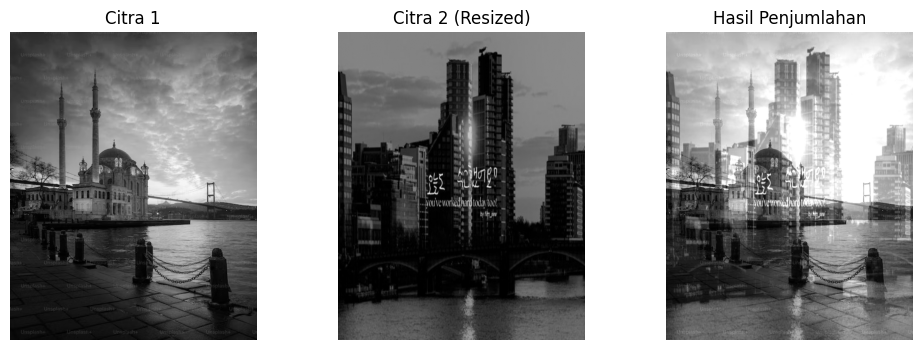

In [17]:
img2 = cv2.imread('/img2.jpg', cv2.IMREAD_GRAYSCALE)

# Proses Resizing jika ukuran berbeda [cite: 108, 109, 114]
if img1.shape != img2.shape:
    print(f"Ukuran berbeda! Resizing Citra 2 dari {img2.shape} menjadi {img1.shape}")
    img2_resized = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
else:
    img2_resized = img2

# Lakukan penjumlahan citra [cite: 105, 106]
# Gunakan np.clip agar nilai tidak overflow melewati 255 [cite: 120]
img_sum_clipped = np.clip(img1.astype(np.int32) + img2_resized.astype(np.int32), 0, 255).astype(np.uint8)

# Visualisasi [cite: 109]
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(img1, cmap='gray'); plt.title('Citra 1'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(img2_resized, cmap='gray'); plt.title('Citra 2 (Resized)'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(img_sum_clipped, cmap='gray'); plt.title('Hasil Penjumlahan'); plt.axis('off')
plt.show()

B3. Operasi Penggeseran (Translasi) Citra

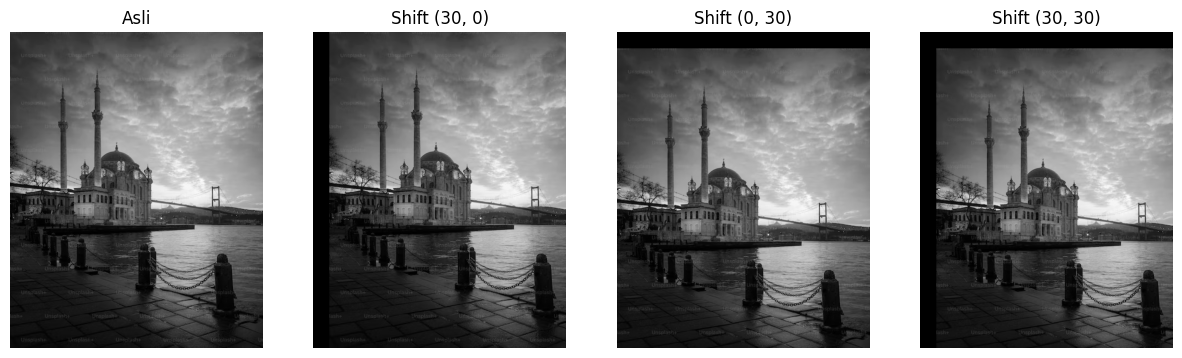

In [18]:
def translate_image(image, dx, dy):
    rows, cols = image.shape
    M = np.float32([[1, 0, dx], [0, 1, dy]]) # Matriks translasi
    return cv2.warpAffine(image, M, (cols, rows))

# Sesuai instruksi kombinasi pergeseran [cite: 125, 126, 127, 128]
img_shift1 = translate_image(img1, 30, 0)   # Delta i=30, Delta j=0
img_shift2 = translate_image(img1, 0, 30)   # Delta i=0, Delta j=30
img_shift3 = translate_image(img1, 30, 30) # Delta i=30, Delta j=30

# Tampilkan perbandingan [cite: 129]
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1); plt.imshow(img1, cmap='gray'); plt.title('Asli'); plt.axis('off')
plt.subplot(1, 4, 2); plt.imshow(img_shift1, cmap='gray'); plt.title('Shift (30, 0)'); plt.axis('off')
plt.subplot(1, 4, 3); plt.imshow(img_shift2, cmap='gray'); plt.title('Shift (0, 30)'); plt.axis('off')
plt.subplot(1, 4, 4); plt.imshow(img_shift3, cmap='gray'); plt.title('Shift (30, 30)'); plt.axis('off')
plt.show()

B4. Operasi Amplifikasi Citra & Histogram

Text(0.5, 1.0, 'Histogram alpha = 0.5')

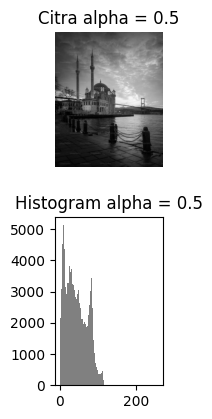

In [21]:
# Operasi perkalian skalar matriks citra
img_amp = np.clip(a * img1.astype(np.float32), 0, 255).astype(np.uint8)

    # Plot Citra
plt.subplot(2, 4, i+1)
plt.imshow(img_amp, cmap='gray')
plt.title(f'Citra alpha = {a}')
plt.axis('off')

    # Plot Histogram
plt.subplot(2, 4, i+5)
plt.hist(img_amp.ravel(), bins=256, range=(0, 256), color='gray')
plt.title(f'Histogram alpha = {a}')

3. BAGIAN C : Uji Sistem Linier

C1. Uji Homogenitas Sistem

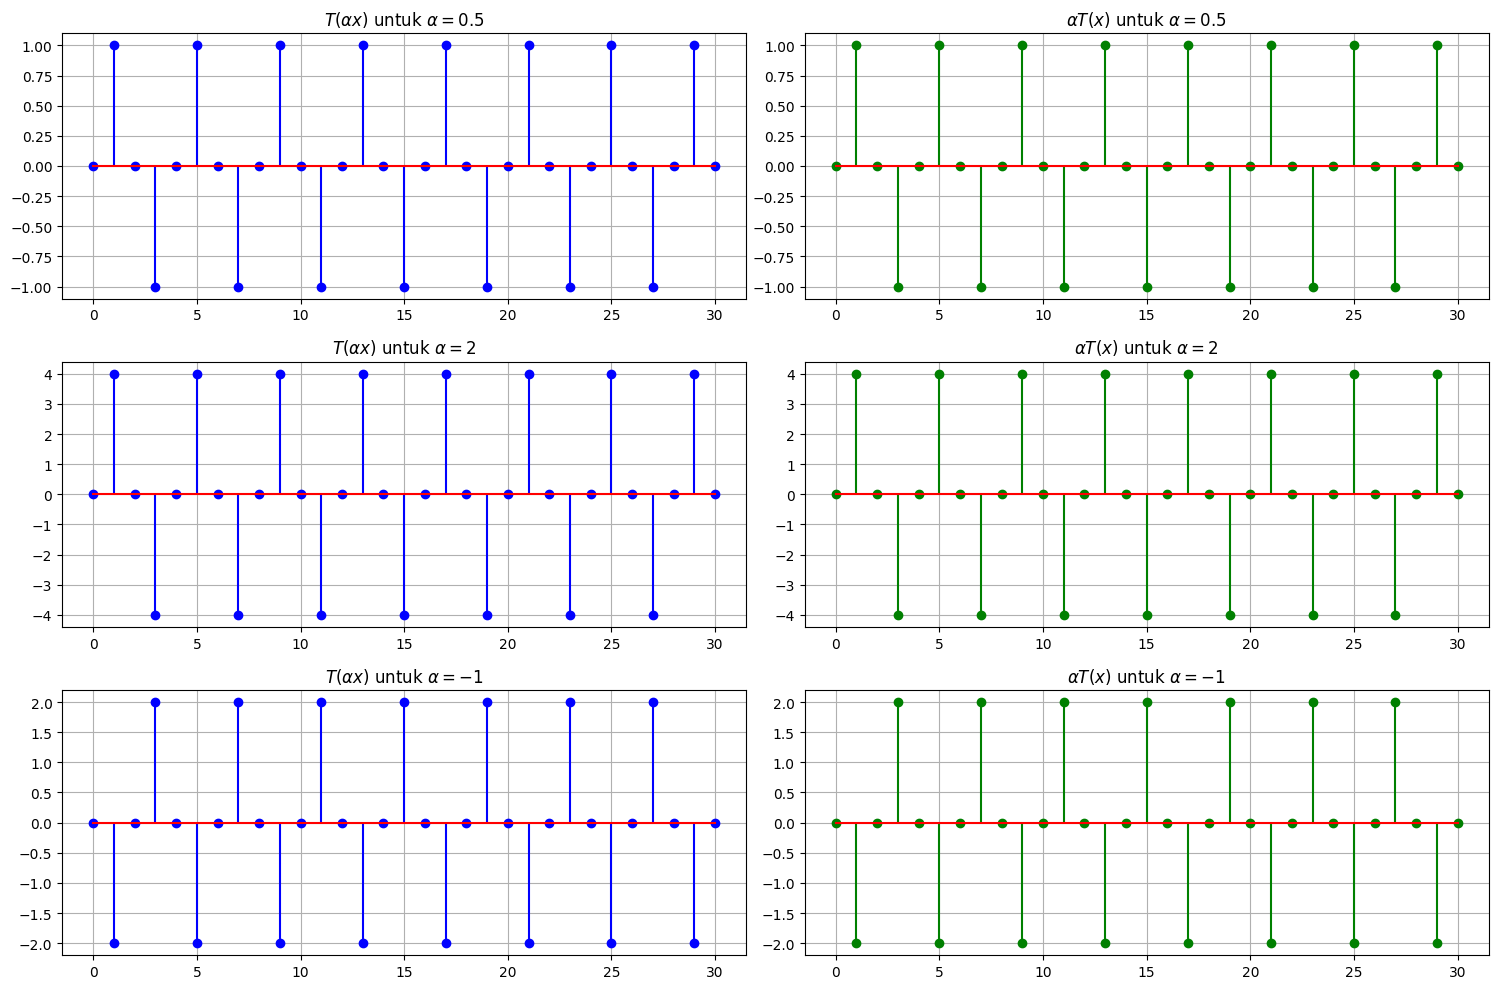

--- Kesimpulan Uji Homogenitas T(x) = 2x ---
Apakah T(alpha * x) == alpha * T(x) untuk alpha=0.5 True


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Mendefinisikan sistem T(x) = 2x
def T(x):
    return 2 * x

# Membuat ulang sinyal x1[n] untuk berjaga-jaga (jika belum ada di memori)
n = np.arange(0, 31)
x_n = np.sin(0.5 * np.pi * n)

# Menentukan nilai konstanta alpha (minimal 3 nilai sesuai instruksi)
alphas = [0.5, 2, -1]

plt.figure(figsize=(15, 10))

for i, alpha in enumerate(alphas):
    # 1. Sisi Kiri: T(alpha * x)
    left_side = T(alpha * x_n)

    # 2. Sisi Kanan: alpha * T(x)
    right_side = alpha * T(x_n)

    # Plot T(alpha * x)
    plt.subplot(3, 2, 2*i + 1)
    plt.stem(n, left_side, linefmt='b-', markerfmt='bo', basefmt='r-')
    plt.title(rf'$T(α x)$ untuk $α = {alpha}$', usetex=False) # Changed to raw f-string and unicode alpha
    plt.grid(True)

    # Plot alpha * T(x)
    plt.subplot(3, 2, 2*i + 2)
    plt.stem(n, right_side, linefmt='g-', markerfmt='go', basefmt='r-')
    plt.title(rf'$α T(x)$ untuk $α = {alpha}$', usetex=False) # Changed to raw f-string and unicode alpha
    plt.grid(True)

plt.tight_layout()
plt.show()

# Pengecekan Kesimpulan Komputasi
print("--- Kesimpulan Uji Homogenitas T(x) = 2x ---")
alpha_for_check = alphas[0] # Using 0.5 for the check
is_homogeneous = np.allclose(T(alpha_for_check * x_n), alpha_for_check * T(x_n))
print(f"Apakah T(alpha * x) == alpha * T(x) untuk alpha={alpha_for_check} {is_homogeneous}")

C2. Uji Additivitas

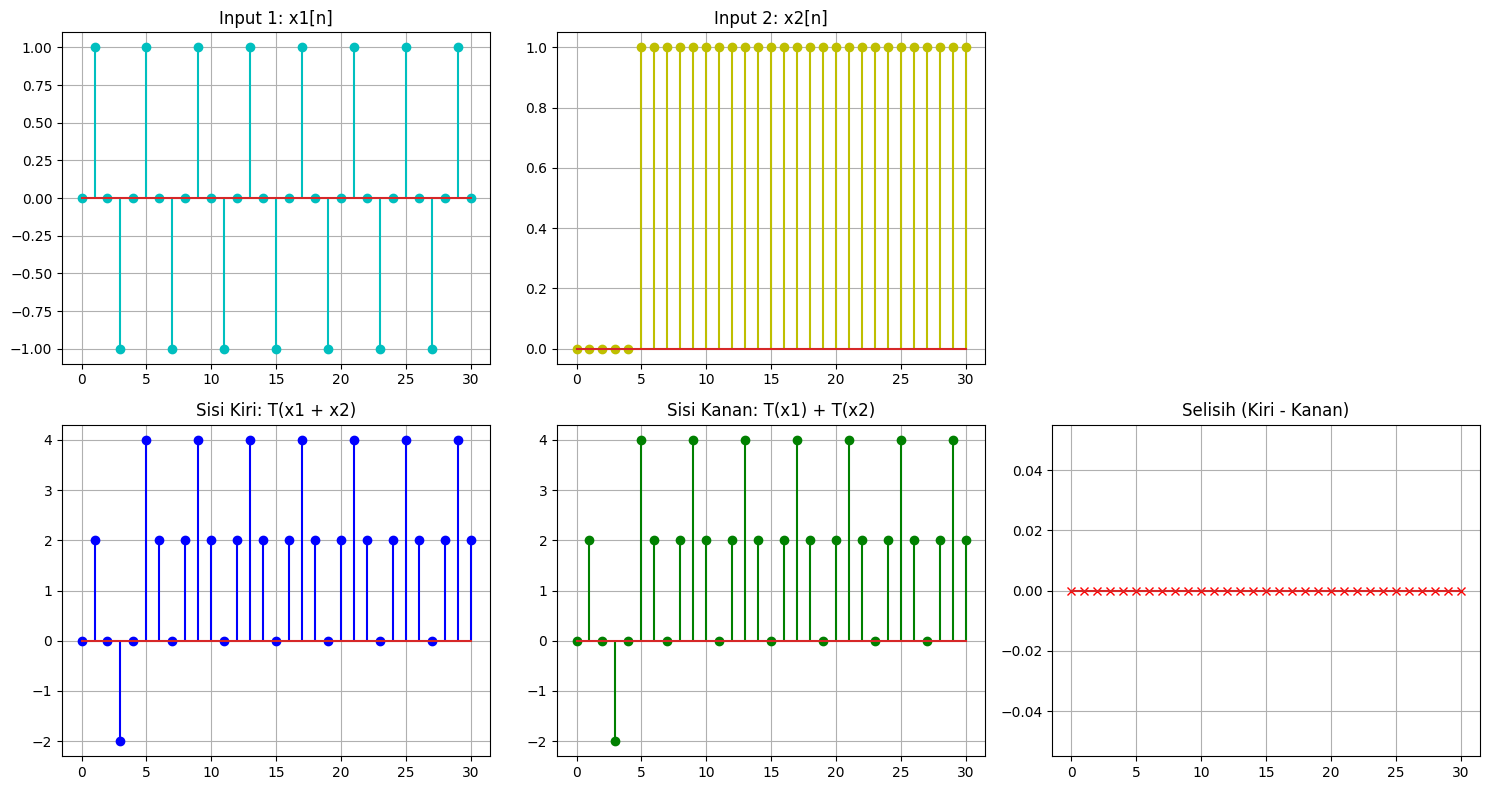

--- Kesimpulan Uji Additivitas T(x) = 2x ---
Apakah T(x1 + x2) == T(x1) + T(x2) True


In [28]:
x1 = np.sin(0.5 * np.pi * n)
x2 = np.where(n >= 5, 1.0, 0.0)

# 1. Sisi Kiri: T(x1 + x2)
left_add = T(x1 + x2)

# 2. Sisi Kanan: T(x1) + T(x2)
right_add = T(x1) + T(x2)

# 3. Menghitung selisih (harus 0 jika identik)
difference = left_add - right_add

# Visualisasi
plt.figure(figsize=(15, 8))

# Plot x1 dan x2 (Input)
plt.subplot(2, 3, 1)
plt.stem(n, x1, linefmt='c-')
plt.title('Input 1: x1[n]')
plt.grid(True)

plt.subplot(2, 3, 2)
plt.stem(n, x2, linefmt='y-')
plt.title('Input 2: x2[n]')
plt.grid(True)

# Plot T(x1 + x2)
plt.subplot(2, 3, 4)
plt.stem(n, left_add, linefmt='b-', markerfmt='bo')
plt.title('Sisi Kiri: T(x1 + x2)')
plt.grid(True)

# Plot T(x1) + T(x2)
plt.subplot(2, 3, 5)
plt.stem(n, right_add, linefmt='g-', markerfmt='go')
plt.title('Sisi Kanan: T(x1) + T(x2)')
plt.grid(True)

# Plot Selisih
plt.subplot(2, 3, 6)
plt.stem(n, difference, linefmt='r-', markerfmt='rx')
plt.title('Selisih (Kiri - Kanan)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Pengecekan Kesimpulan Komputasi
print("--- Kesimpulan Uji Additivitas T(x) = 2x ---")
is_additive = np.allclose(left_add, right_add)
print(f"Apakah T(x1 + x2) == T(x1) + T(x2) {is_additive}")

C3. Perbandingan Sistem Linier dan Non-Linier

In [29]:
def T2(x):
    return x ** 2

alpha_test = 3.0

# Uji T2(x) = x^2
homo_left_t2 = T2(alpha_test * x1)
homo_right_t2 = alpha_test * T2(x1)
is_homo_t2 = np.allclose(homo_left_t2, homo_right_t2)

add_left_t2 = T2(x1 + x2)
add_right_t2 = T2(x1) + T2(x2)
is_add_t2 = np.allclose(add_left_t2, add_right_t2)

print(f"--- Uji Sistem T2(x) = x^2 ---")
print(f"Memenuhi Homogenitas? {is_homo_t2}")
print(f"Memenuhi Additivitas? {is_add_t2}")

--- Uji Sistem T2(x) = x^2 ---
Memenuhi Homogenitas? False
Memenuhi Additivitas? False
